In [1]:
import pandas as pd

#### **Part A: Data Understanding and Preprocessing**

#### *1. Load the dataset and explore:*
- Display first 10 rows.
- Plot temperature trends over time.
- Check for missing values.

In [2]:
df = pd.read_csv('weatherHistory.csv')

In [3]:
df.columns
df.head(10)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
5,2006-04-01 05:00:00.000 +0200,Partly Cloudy,rain,9.222222,7.111111,0.85,13.9587,258.0,14.9569,0.0,1016.66,Partly cloudy throughout the day.
6,2006-04-01 06:00:00.000 +0200,Partly Cloudy,rain,7.733333,5.522222,0.95,12.3648,259.0,9.9820,0.0,1016.72,Partly cloudy throughout the day.
7,2006-04-01 07:00:00.000 +0200,Partly Cloudy,rain,8.772222,6.527778,0.89,14.1519,260.0,9.9820,0.0,1016.84,Partly cloudy throughout the day.
8,2006-04-01 08:00:00.000 +0200,Partly Cloudy,rain,10.822222,10.822222,0.82,11.3183,259.0,9.9820,0.0,1017.37,Partly cloudy throughout the day.
9,2006-04-01 09:00:00.000 +0200,Partly Cloudy,rain,13.772222,13.772222,0.72,12.5258,279.0,9.9820,0.0,1017.22,Partly cloudy throughout the day.


In [4]:
df.dtypes

Formatted Date               object
Summary                      object
Precip Type                  object
Temperature (C)             float64
Apparent Temperature (C)    float64
Humidity                    float64
Wind Speed (km/h)           float64
Wind Bearing (degrees)      float64
Visibility (km)             float64
Loud Cover                  float64
Pressure (millibars)        float64
Daily Summary                object
dtype: object

In [5]:
import matplotlib.pyplot as plt

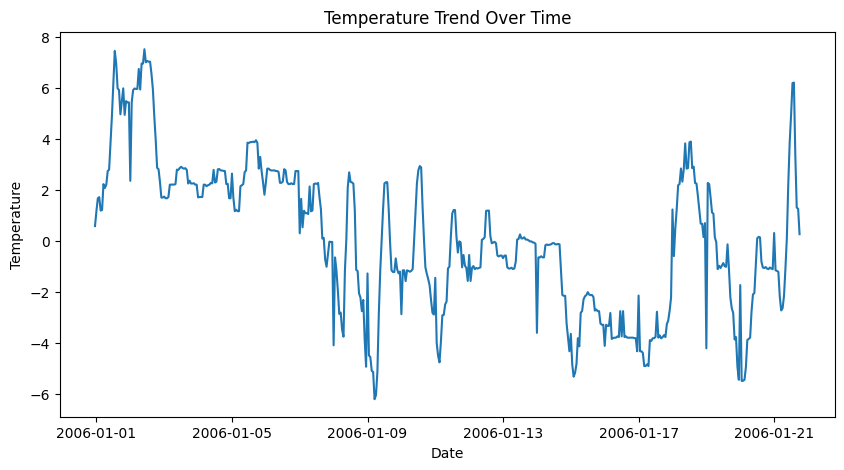

In [6]:
df = df.sort_values('Formatted Date')
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'],utc=True)

plt.figure(figsize=(10,5))
df_sample = df.iloc[:500]   # first 500 rows

plt.plot(df_sample['Formatted Date'], df_sample['Temperature (C)'])
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Temperature Trend Over Time")
plt.show()

<h4>Observation</h4>
<span style="color:green"><b>The temperature data shows continuous fluctuations over time with short-term dependencies, indicating that future values depend on past observations.This makes it suitable for time-series modeling using RNN.</b></span> 

In [7]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

#### *2. Preprocess the data:*
- Handle missing values (impute/remove).
- Normalize values using MinMaxScaler (so RNN converges faster).
- Create input sequences:
    ■ Use past 7–14 days’ weather data (temperature, humidity, wind speed)
        as input.
    ■ Target: next day’s temperature.
- Split dataset into train, validation, and test sets.

In [8]:
features = df[['Temperature (C)','Humidity','Wind Speed (km/h)']]
features

,Temperature (C),Humidity,Wind Speed (km/h)
2880,0.577778,0.89,17.1143
2881,1.161111,0.85,16.6152
2882,1.666667,0.82,20.2538
2883,1.711111,0.82,14.4900
2884,1.183333,0.86,13.9426
...,...,...,...
89728,0.488889,0.86,9.7566
89729,0.072222,0.88,9.4185
89730,-0.233333,0.89,9.2736
89731,-0.472222,0.91,9.2414


- NORMALIZATION

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(features)
print(len(scaled_data))

96453


In [10]:
import numpy as np

sequence_length = 7
X = []
y = []
for i in range(len(scaled_data) - sequence_length):
    X.append(scaled_data[i:i+sequence_length])
    y.append(scaled_data[i+sequence_length][0])  
X = np.array(X)
y = np.array(y)

- Split data

In [11]:
print(len(X))

96446


In [12]:
train_size = int(0.7 * len(X))   # 70%
val_size = int(0.15 * len(X))    # 15%
X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(67512, 7, 3)
(14466, 7, 3)
(14468, 7, 3)


<span style="color:Blue"><b>Split = 70% train + 15% val + 15% test</b></span> 
<span style="color:green"><b>Since it is time-series data, I split the dataset sequentially without shuffling, using earlier data for training, middle for validation, and latest data for testing.</b></span> 

#### **Part B: RNN Model Development**

#### *3. Build a SimpleRNN model using TensorFlow/Keras:*
- Input layer (with shape = sequence length × number of features).
- SimpleRNN layer (e.g., 32–64 units).
- Dropout layer (optional, to avoid overfitting).
- Dense layer with 1 unit (linear activation for regression).

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, Input

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    SimpleRNN(32, activation='tanh', return_sequences=False), 
    Dropout(0.2),
    Dense(1)
])

#### *4. Compile the model:*
- Loss: Mean Squared Error (MSE).
- Optimizer: Adam.
- Metrics: Mean Absolute Error (MAE).

In [39]:
model.compile(
    loss='mse',
    optimizer='adam',
    metrics=['mae']
)

#### *5. Train the model on training data:*
- Batch size: 32
- Epochs: 50–100
- Use validation data to monitor performance.
- Plot training vs validation loss curves.

<span style="color:green"><b>- TRAIN THE MODEL</b></span>

In [40]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 0.0082 - mae: 0.0601 - val_loss: 5.5577e-04 - val_mae: 0.0181
Epoch 2/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0018 - mae: 0.0324 - val_loss: 3.8519e-04 - val_mae: 0.0145
Epoch 3/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0011 - mae: 0.0247 - val_loss: 3.6914e-04 - val_mae: 0.0150
Epoch 4/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 8.7692e-04 - mae: 0.0224 - val_loss: 2.9448e-04 - val_mae: 0.0130
Epoch 5/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 7.9689e-04 - mae: 0.0212 - val_loss: 3.3994e-04 - val_mae: 0.0135
Epoch 6/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 7.6557e-04 - mae: 0.0207 - val_loss: 3.0226e-04 - val_mae: 0.0129
Epoch 7/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 7.3335e-04 - mae: 0.0202 - val_loss: 2.8275e-04 - val_mae: 0.0122
Epoch 8/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - loss: 7.2500e-04 - mae: 0.0200 - val_loss: 2.8332e-0

<span style="color:green"><b>- PLOT LOSS CURVES</b></span>

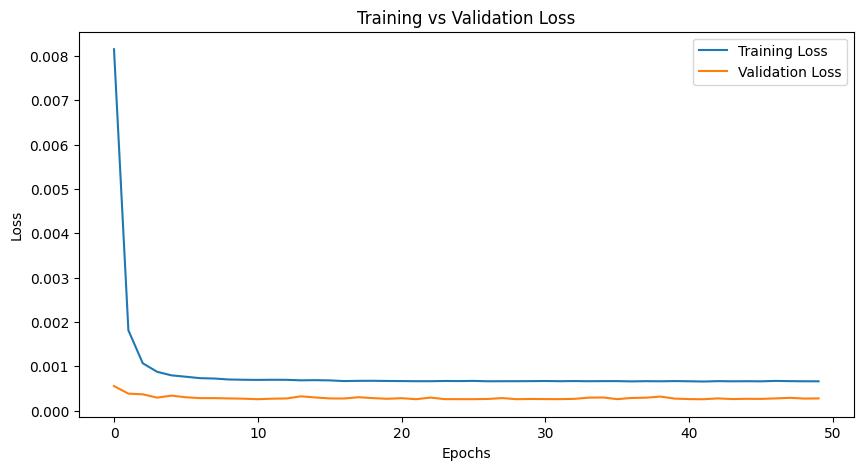

In [41]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.show()

#### **Part C: Model Evaluation & Forecasting**

#### *6. Evaluate the model on the test set:*
- Calculate RMSE, MAE, and R2 score.
- Plot predicted vs actual temperatures for the test period.

In [53]:
y_pred = model.predict(X_test)

453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [54]:
import numpy as np

y_pred_full = np.zeros((len(y_pred), 3))
y_test_full = np.zeros((len(y_test), 3))

y_pred_full[:, 0] = y_pred.flatten()
y_test_full[:, 0] = y_test

y_pred_actual = scaler.inverse_transform(y_pred_full)[:, 0]
y_test_actual = scaler.inverse_transform(y_test_full)[:, 0]

In [55]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 1.0312980727941796
MAE: 0.7449102755666405
R2 Score: 0.9875494516416561


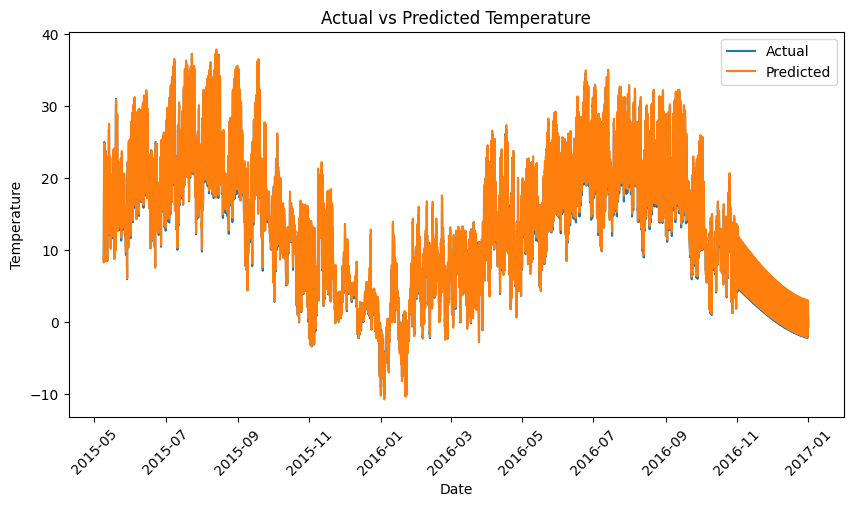

In [60]:
dates_test = df['Formatted Date'].iloc[-len(y_test_actual):]

plt.figure(figsize=(10,5))
plt.plot(dates_test, y_test_actual, label='Actual')
plt.plot(dates_test, y_pred_actual, label='Predicted')

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.xticks(rotation=45)
plt.show()

#### *7. Forecast the next 7 days of temperature using the trained model and visualize predictions vs recent historical data.*

In [61]:
seq = scaled_data[-7:]
future_preds = []

for _ in range(7):
    pred = model.predict(seq.reshape(1,7,3))[0][0]
    future_preds.append(pred)

    next_row = seq[-1].copy()
    next_row[0] = pred
    seq = np.vstack((seq[1:], next_row))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


In [62]:
temp_min, temp_max = scaler.data_min_[0], scaler.data_max_[0]
future_actual = np.array(future_preds) * (temp_max - temp_min) + temp_min

In [64]:
last_date = df['Formatted Date'].iloc[-1]
future_dates = pd.date_range(start=last_date, periods=8, freq='D')[1:]

recent_dates = df['Formatted Date'].iloc[-50:]
recent_actual = y_test_actual[-50:]

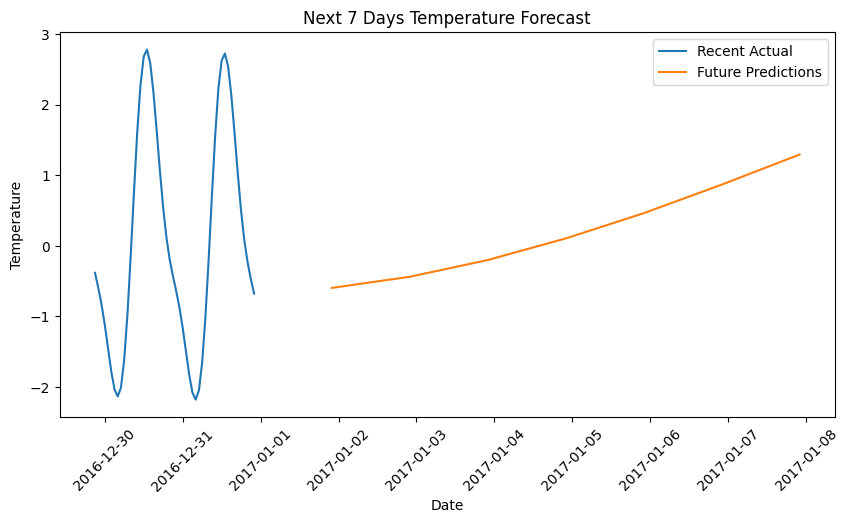

In [65]:
plt.figure(figsize=(10,5))

plt.plot(recent_dates, recent_actual, label='Recent Actual')
plt.plot(future_dates, future_actual, label='Future Predictions')

plt.title("Next 7 Days Temperature Forecast")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.xticks(rotation=45)
plt.show()